<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/Cohort_and_RFM_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Introduction to Cohort and RFM Analysis**
---



In the realm of data-driven marketing and analytics, businesses are constantly looking for ways to understand and leverage customer behavior to drive growth and profitability. Two powerful tools in this endeavor are cohort analysis and recency, frequency, and monetary (RFM) analysis.

Cohort analysis involves segmenting customers based on shared characteristics or experiences over a defined time period. RFM analysis, on the other hand, focuses on segmenting customers based on recent purchasing activity, transaction frequency, and monetary value.

Combining cohort analysis with RFM analysis provides businesses with a comprehensive understanding of customer behavior and segmentation. By leveraging insights from both approaches, businesses can make informed decisions to improve customer acquisition, retention, and overall profitability. Whether understanding the behavior of specific customer groups over time or segmenting customers based on recency, frequency, and monetary value, these analytical techniques play a crucial role in driving marketing success in today's highly competitive environment.


In [39]:
# data manipulation
import numpy as np  # useful for many scientific computing in Python
import pandas as pd # primary data structure library

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# other displays
import warnings
warnings.filterwarnings('ignore')

## **1. What is Cohort Analysis?**

A cohort is a group of users who share something in common, such as their signup date, month of first purchase, birth date, acquisition channel, etc. Cohort analysis is a method by which these groups are tracked over time, helping us spot trends, understand recurring behavior (purchases, engagement, amount spent, etc.), and monitor customer retention and revenue.

Typically, cohorts are created based on a customer's first use of the platform, where "usage" depends on our key business metrics. For Uber or Lyft, usage would be booking a ride through one of their apps. For GrubHub, it would be ordering food. For Airbnb, it would be booking a hotel room.

With these companies, purchasing is at the core of their service, whether it's taking a ride or booking dinner—their revenue is tied to their users' purchasing behavior.

When building cohort analysis, it's important to consider the relationship between the events or interactions we track and their relationship to our business model.

## **2. Why is it valuable?**

Cohort analysis can help us understand the health of our business and the "stickiness"—the loyalty of our customers. Customer loyalty is crucial because it is much cheaper and easier to retain existing customers than to acquire new ones. For startups, it is also a key indicator of product-market fit.

Furthermore, our products evolve over time. New features are added and removed, designs change, etc. Observing individual cohorts over time is a starting point for understanding how these changes affect user behavior.

It's also a good way to visualize our user retention/churn and develop a basic understanding of their lifetime value.

## **3. Cohort Analysis with Python**

Next, we'll demonstrate how to perform a cohort analysis in Python.

In [3]:
# Loading dataset
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vTvYHIm0lvqQrMuLal8FlxbFKToMB7ZuqWhSfoZhJ-MlfSDmcH4GOLHkH5JjnuIuzlTbAMvZceyeTIJ/pub?output=csv'
df = pd.read_csv(
  url,
  parse_dates=['InvoiceDate'], # converts the InvoiceDate column to a datetime
  dtype={'CustomerID': str} # converts the CustomerID column to a string
)
df.sample(5, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
47403,545819,21175,GIN + TONIC DIET METAL SIGN,2,2011-07-03 12:31:00,2.55,16356,United Kingdom
336821,577479,23265,SET OF 3 WOODEN TREE DECORATIONS,12,2011-11-20 11:34:00,1.25,14911,EIRE
307418,574720,72232,FENG SHUI PILLAR CANDLE,12,2011-06-11 14:39:00,0.19,14547,United Kingdom
376215,581169,22804,PINK HANGING HEART T-LIGHT HOLDER,6,2011-07-12 14:54:00,2.95,16779,United Kingdom
160692,559934,21903,MAN FLU METAL SIGN,12,2011-07-14 09:58:00,2.10,13012,United Kingdom


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379979 entries, 0 to 379978
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    379979 non-null  object        
 1   StockCode    379979 non-null  object        
 2   Description  379979 non-null  object        
 3   Quantity     379979 non-null  int64         
 4   InvoiceDate  379979 non-null  datetime64[ns]
 5   UnitPrice    379979 non-null  float64       
 6   CustomerID   379979 non-null  object        
 7   Country      379979 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 23.2+ MB


Note that we use `parse_dates` to convert **InvoiceDate** from an object to a datetime. Then we also use `dtype` to convert **CustomerID** from an integer to an object.

Next, we'll create the cohort in a few steps.

### `1. Create a period column based on the OrderDate`

Since we're working with a monthly cohort, we'll be looking at the total monthly behavior of the user. Therefore, we don't want detailed InvoiceDate data (at this time).

In [5]:
df['InvoicePeriod'] = df['InvoiceDate'].dt.to_period('M')
df.sample(5, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoicePeriod
47403,545819,21175,GIN + TONIC DIET METAL SIGN,2,2011-07-03 12:31:00,2.55,16356,United Kingdom,2011-07
336821,577479,23265,SET OF 3 WOODEN TREE DECORATIONS,12,2011-11-20 11:34:00,1.25,14911,EIRE,2011-11
307418,574720,72232,FENG SHUI PILLAR CANDLE,12,2011-06-11 14:39:00,0.19,14547,United Kingdom,2011-06
376215,581169,22804,PINK HANGING HEART T-LIGHT HOLDER,6,2011-07-12 14:54:00,2.95,16779,United Kingdom,2011-07
160692,559934,21903,MAN FLU METAL SIGN,12,2011-07-14 09:58:00,2.10,13012,United Kingdom,2011-07


Note that `dt.to_period('M')` is used to change the datetime format to yyyy-mm.

### `2. Determine the user's cohort group (based on their first order)`

Create a new column called CohortGroup, which in this case represents the year and month of the user's first transaction. In other cases, the cohort group could be the date/time of a user's first activity, such as the date of their first purchase, the date of their first login, the month of their first transaction, the date of their first subscription, and so on.

In [6]:
# displays the first purchase month of each CustomerID
df.groupby('CustomerID')['InvoicePeriod'].min()

,InvoicePeriod
CustomerID,
12346,2011-01
12347,2011-01
12348,2011-01
12349,2011-11
12350,2011-02
...,...
18280,2011-07
18281,2011-12
18282,2011-02


In [7]:
df['CohortGroup'] = df.groupby('CustomerID')['InvoicePeriod'].transform('min')
df.sample(5, random_state=42)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoicePeriod,CohortGroup
47403,545819,21175,GIN + TONIC DIET METAL SIGN,2,2011-07-03 12:31:00,2.55,16356,United Kingdom,2011-07,2011-04
336821,577479,23265,SET OF 3 WOODEN TREE DECORATIONS,12,2011-11-20 11:34:00,1.25,14911,EIRE,2011-11,2011-01
307418,574720,72232,FENG SHUI PILLAR CANDLE,12,2011-06-11 14:39:00,0.19,14547,United Kingdom,2011-06,2011-05
376215,581169,22804,PINK HANGING HEART T-LIGHT HOLDER,6,2011-07-12 14:54:00,2.95,16779,United Kingdom,2011-07,2011-01
160692,559934,21903,MAN FLU METAL SIGN,12,2011-07-14 09:58:00,2.10,13012,United Kingdom,2011-07,2011-02


Note that we're using `transform`, which acts like a window function in SQL.
With `transform`, the number of rows is maintained and the values displayed are based on the aggregate function we entered into the function.

###  `3. Rollup data by CohortGroup & InvoicePeriod`

Selanjutnya kita akan melakukan agregasi berdasarkan CohortGroup dan InvoicePeriod-nya. Adapun fungsi agregat dan kolom yang dipakai disesuaikan dengan kebutuhan.

Misal dalam kasus ini kita ingin melihat berapa banyak user berbeda yang melakukan pembelian berdasarkan Cohort Date dan Current Activity Date, maka kita akan menggunakan `nunique` terhadap kolom **CustomerID**.

In [8]:
df.groupby(['CohortGroup', 'InvoicePeriod'], as_index=False)[['CustomerID']].nunique()

,CohortGroup,InvoicePeriod,CustomerID
0,2011-01,2011-01,967
1,2011-01,2011-02,320
2,2011-01,2011-03,368
3,2011-01,2011-04,338
4,2011-01,2011-05,381
...,...,...,...
73,2011-10,2011-11,53
74,2011-10,2011-12,10
75,2011-11,2011-11,244
76,2011-11,2011-12,11


In [9]:
cohort = df.groupby(['CohortGroup', 'InvoicePeriod'], as_index=False).agg(
  n_customers=('CustomerID', 'nunique')
)

cohort
# desired_column_name = (column_name_to_aggregate, aggregate_function)

,CohortGroup,InvoicePeriod,n_customers
0,2011-01,2011-01,967
1,2011-01,2011-02,320
2,2011-01,2011-03,368
3,2011-01,2011-04,338
4,2011-01,2011-05,381
...,...,...,...
73,2011-10,2011-11,53
74,2011-10,2011-12,10
75,2011-11,2011-11,244
76,2011-11,2011-12,11


### `4. Label the PeriodDistance for each CohortGroup`

We want to see the behavior of each cohort in the months following their first transaction, so we need to index each cohort to the month of their first transaction. For example, PeriodDistance = 0 indicates the time the cohort made their first transaction, PeriodDistance = 1 indicates 1 month after their first transaction, and so on.

This allows us to compare cohorts across different stages of their lives.

In [10]:
from operator import attrgetter

cohort['PeriodDistance'] = (cohort['InvoicePeriod'] - cohort['CohortGroup']).apply(attrgetter('n'))
cohort

,CohortGroup,InvoicePeriod,n_customers,PeriodDistance
0,2011-01,2011-01,967,0
1,2011-01,2011-02,320,1
2,2011-01,2011-03,368,2
3,2011-01,2011-04,338,3
4,2011-01,2011-05,381,4
...,...,...,...,...
73,2011-10,2011-11,53,1
74,2011-10,2011-12,10,2
75,2011-11,2011-11,244,0
76,2011-11,2011-12,11,1


### `5. Calculate percentage change of each CohortGroup over time`

We want to see the percentage change of each CohortGroup over time -- not the absolute change.

To do this, we first need to create a new column containing the size of each CohortGroup.

In [11]:
cohort['CohortSize'] = cohort.groupby('CohortGroup')['n_customers'].transform('max')
cohort.head()

,CohortGroup,InvoicePeriod,n_customers,PeriodDistance,CohortSize
0,2011-01,2011-01,967,0,967
1,2011-01,2011-02,320,1,967
2,2011-01,2011-03,368,2,967
3,2011-01,2011-04,338,3,967
4,2011-01,2011-05,381,4,967


Next we calculate the percentage.

In [12]:
cohort['Percentage'] = round(cohort['n_customers']/cohort['CohortSize']*100, 2)
cohort

,CohortGroup,InvoicePeriod,n_customers,PeriodDistance,CohortSize,Percentage
0,2011-01,2011-01,967,0,967,100.00
1,2011-01,2011-02,320,1,967,33.09
2,2011-01,2011-03,368,2,967,38.06
3,2011-01,2011-04,338,3,967,34.95
4,2011-01,2011-05,381,4,967,39.40
...,...,...,...,...,...,...
73,2011-10,2011-11,53,1,266,19.92
74,2011-10,2011-12,10,2,266,3.76
75,2011-11,2011-11,244,0,244,100.00
76,2011-11,2011-12,11,1,244,4.51


### `6. Create pivot table by Cohort Group`

Next, we will create a pivot table that displays user retention rates over time.

In [13]:
cohort_pivot = cohort.pivot_table(
    index='CohortGroup',
    columns='PeriodDistance',
    values='Percentage'
)

cohort_pivot

PeriodDistance,0,1,2,3,4,5,6,7,8,9,10,11
CohortGroup,,,,,,,,,,,,
2011-01,100.0,33.09,38.06,34.95,39.40,41.05,40.95,35.26,43.12,42.71,49.74,19.75
2011-02,100.0,25.28,26.20,30.63,30.63,31.92,29.89,31.18,31.73,37.27,10.89,NaN
2011-03,100.0,21.80,24.20,24.60,25.80,22.60,24.00,27.40,28.80,7.00,NaN,NaN
2011-04,100.0,22.45,21.93,21.41,19.58,19.84,27.68,25.59,6.27,NaN,NaN,NaN
2011-05,100.0,19.74,20.71,17.48,24.92,18.77,28.48,7.44,NaN,NaN,NaN,NaN
2011-06,100.0,18.15,17.52,20.38,19.43,27.71,6.69,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,19.84,18.65,21.03,26.19,3.97,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,17.20,23.66,27.96,5.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-09,100.0,15.69,21.57,2.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 7. Visualize

For the final stage, we will create visualizations in the form of heatmaps and lineplots.

**Heatmap**

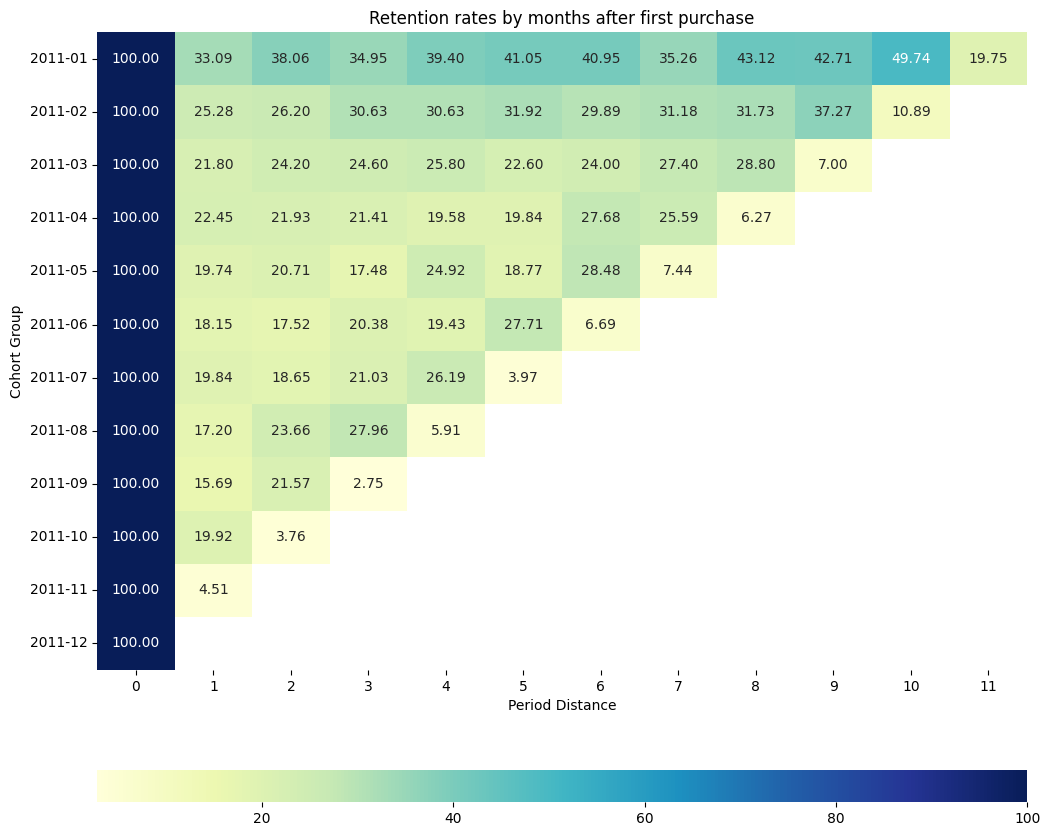

In [18]:
grid = {
'height_ratios': (20,1), # sets the height ratio between subplot 1 and subplot 2
'hspace': 0.3 # sets the spacing between subplot 1 and subplot 2
}

fig, (ax_top, ax_bot) = plt.subplots(nrows=2, ncols=1, figsize=(12,10), gridspec_kw=grid)

sns.heatmap(
  cohort_pivot,
  annot=True, # adds annotations/data labels
  fmt='.2f', # format of the annotation
  cmap='YlGnBu',
  ax=ax_top, # places the heatmap on subplot 1
  cbar_ax=ax_bot, # places the colorbar on subplot 2
  cbar_kws={'orientation':'horizontal'} # changes the orientation of the colorbar
)

ax_top.set(
  title='Retention rates by months after first purchase',
  xlabel='Period Distance',
  ylabel='Cohort Group'
)

plt.show()

**Insight**

- Horizontally (left to right), for each cohort, the percentage of customers fluctuates quite significantly from month to month.
- Vertically (top to bottom), if we look at Month Distance 1, the percentage of customers in newer cohorts tends to be lower (less loyal) than in older cohorts.
- The January 2011 cohort (2011-01) is the most loyal (retained) cohort.
- The highest percentage of customers occurred in the January cohort (2011-01) in month 10, at 49.74%.
- The lowest percentage of customers occurred in the September cohort (2011-09) in month 3, at 2.75%.
- In November 2011, all cohorts experienced an increase in the number of customers (assuming Black Friday).

**Line plot**

In [19]:
cohort_pivot.index

PeriodIndex(['2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06',
             '2011-07', '2011-08', '2011-09', '2011-10', '2011-11', '2011-12'],
            dtype='period[M]', name='CohortGroup')

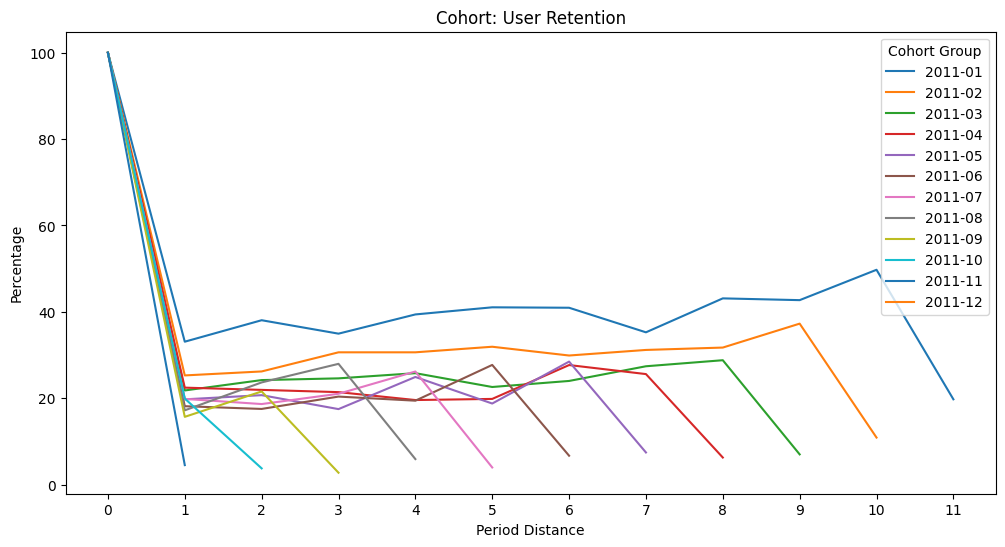

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

for cohort in cohort_pivot.index:
  ax.plot(
    cohort_pivot.columns, # x-axis
    cohort_pivot.loc[cohort], # y-axis
    label=cohort
  )

ax.set(
  title='Cohort: User Retention', # title
  xlabel='Period Distance', # labels on the x-axis
  ylabel='Percentage', # labels on the y-axis
  xticks=np.arange(len(cohort_pivot)) # sets the ticks of the x-axis
)

ax.legend(loc='upper right', title='Cohort Group')
plt.show()

## **4. What is RFM Analysis?**

RFM Analysis is an analysis method used to segment customers based on customer habits. The metrics analyzed are as follows:

- `Recency`: How long ago the customer made a purchase.
- `Frequency`: How often the customer made a transaction.
- `Monetary`: The amount the customer spent on a transaction.

![](https://clevertap.com/wp-content/uploads/2018/03/Incontent_image.png)

RFM metrics are typically used to identify customer characteristics. They can also be used to determine a customer's value. Is customer A a loyal customer? Does customer A consistently make large transactions? and so on. Using these metrics, customer segments are created based on their value, such as high-value, medium-value, and low-value.

## **5. Calculate RFM values**

Now let's calculate the recency, frequency, and monetary values. In this case, we also assume that we want to group our customers into 4 segments with the following conditions:

![](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEibG08VAjnoHCP8LgpmrutFZy9Mftfo9vCmK7H7Zi3ePGJavAp0yITSw5Kyjuw0lHuuz6nCpSfoc4LQb5MbljMtNpIb2wh-0DjCm3sJ22l6tmBw7BsYuRWjGmzlo3-Yp0xKoLIs-wsrjDhYXTMBh6ub2iACVMMPzzdrC65p599RHGB-VXpsCH6sCX9L0Q/s1600/RFM-model.jpg)

In the example above, we use quartiles. We can divide the segment into 3 or 5 segments; the decision is ours.

- Frequency: The higher the frequency, the higher the value.
- Recency: The closer the purchase date, the higher the value. A lower recency means the closest purchase date.
- Monetary: The higher the purchase value, the higher the monetary value.
- Final values: The range is 3 (the minimum value is 1, with three elements) and 12 (the maximum value is 4 for each element).

We can name each segment; in the example above, we use the metal names Platinum, Gold, Silver, and Bronze. We can use names that are relevant to our business.

The final values above are just examples; we can change them to suit the purpose of the analysis.

### `Recency`

Seperti yang sudah dijelaskan pada bagian sebelumnya, recency akan melihat berapa lama waktu customer dalam melakukan transaksi terakhirnya. Oleh karena itu untuk mendapatkan nilai recency, perlu diketahui terlebih dahulu tanggal terakhir customer melakukan transaksi. Selanjutnya akan diselisihkan hari terakhir customer melakukan transaksi dengan hari melakukan analisis. Sebagai asumsi, hari analisis diperoleh dari hari terakhir transaksi + 1.

In [21]:
import datetime

analysis_date = df['InvoiceDate'].max() + datetime.timedelta(1)
analysis_date

Timestamp('2011-12-11 17:19:00')

The next step is to calculate the recency of each customer.

In [22]:
df_recency = df.groupby('CustomerID').agg(
    recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    customer_age=('InvoiceDate', lambda x: (analysis_date - x.min()).days),
)

df_recency.sample(5, random_state=42)

,recency,customer_age
CustomerID,,
15110,25,320
17655,12,286
18200,107,107
12573,229,229
15797,97,321


Looking at the table above, we can see that customer ID 12573 has been shopping at the store for 229 days. This means that customer 12573 hasn't shopped at the store for quite some time. Meanwhile, customer 17655 made her last transaction only 12 days ago, indicating that she's a relatively new shopper at the store.

### `Frequency`
To determine how often customers make transactions, we can analyze the frequency of each customer's purchases.

In [23]:
df_frequency = df.groupby('CustomerID').agg(
    frequency=('InvoiceNo', lambda x: x.nunique()),
)

df_frequency.sample(5, random_state=42)

,frequency
CustomerID,
15110,7
17655,6
18200,1
12573,1
15797,4


Looking at customer 12573, who has been shopping for quite a while, judging by how often he's shopped at the store, he's only been there once—very infrequently. In contrast, customer 17655, who is a fairly frequent shopper, has shopped there six times.

### `Monetary`
Next is monetary, which is how much a customer spends on each transaction. The monetary value can be obtained by multiplying the price of the purchased item by the number of items purchased in a single transaction. We will first create a TotalPrice column that displays the result of multiplying UnitPrice by Quantity.

In [24]:
df['TotalPrice'] = df['Quantity']*df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoicePeriod,CohortGroup,TotalPrice
0,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-04-01 10:00:00,1.95,13313,United Kingdom,2011-04,2011-04,19.5
1,539993,21499,BLUE POLKADOT WRAP,25,2011-04-01 10:00:00,0.42,13313,United Kingdom,2011-04,2011-04,10.5
2,539993,21498,RED RETROSPOT WRAP,25,2011-04-01 10:00:00,0.42,13313,United Kingdom,2011-04,2011-04,10.5
3,539993,22379,RECYCLING BAG RETROSPOT,5,2011-04-01 10:00:00,2.10,13313,United Kingdom,2011-04,2011-04,10.5
4,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-04-01 10:00:00,1.25,13313,United Kingdom,2011-04,2011-04,12.5


The next step is to add up the TotalPrice of each customer.

In [25]:
df_monetary = df.groupby('CustomerID').agg(
    monetary=('TotalPrice', 'sum'),
    avg_spend_per_product=('TotalPrice', 'mean'),
)

df_monetary.sample(5, random_state=42)

,monetary,avg_spend_per_product
CustomerID,,
15110,970.25,24.256250
17655,1962.84,23.937073
18200,163.80,5.118750
12573,160.54,5.733571
15797,2207.40,275.925000


Returning to customer 12573, she noted that she had made one transaction and hadn't made another in a long time. Even that single transaction was relatively small, with a total spend of $160.54. Meanwhile, customer 17655's total spend across six transactions was $1962.84, with an average spend per product of $23.9.

Next, all the information obtained, including recency, frequency, and monetary values, was combined into a single data frame to facilitate analysis for customer segmentation.

In [26]:
df_customer = df.groupby('CustomerID').agg(
    recency=('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    customer_age=('InvoiceDate', lambda x: (analysis_date - x.min()).days),
    frequency=('InvoiceNo', lambda x: x.nunique()),
    monetary=('TotalPrice', 'sum'),
    avg_spend_per_product=('TotalPrice', 'mean'),
)

df_customer.sample(5, random_state=42)

,recency,customer_age,frequency,monetary,avg_spend_per_product
CustomerID,,,,,
15110,25,320,7,970.25,24.256250
17655,12,286,6,1962.84,23.937073
18200,107,107,1,163.80,5.118750
12573,229,229,1,160.54,5.733571
15797,97,321,4,2207.40,275.925000


The following is an explanation of each of the variables above:

| Variable | Description |
| --- | --- |
| customerID | Customer ID|
| customer_age | Customer age, obtained from the difference between the first day of the transaction and the analysis day |
| recency | The difference between the last day of the transaction and the analysis day |
| frequency | Number of transactions made by the customer |
| monetary | Amount spent by the customer |
| avg_spend_per_product | Average amount spent by the customer per product|

### `RFM Segmentation`

**Recency Segmentation**

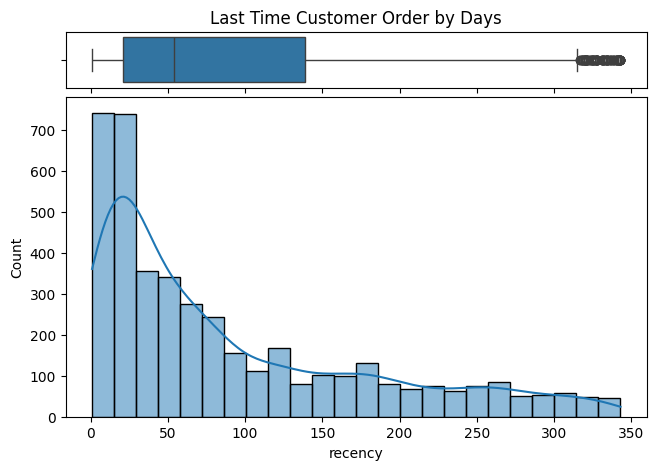

,recency
0.00,1.0
0.25,21.0
0.50,54.0
0.75,139.0
1.00,343.0


In [27]:
grid = {
    'height_ratios': (0.15, 0.85),
    'hspace': 0.05
}

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(7.5, 5), gridspec_kw=grid)

sns.boxplot(data=df_customer, x='recency', ax=ax1)
sns.histplot(data=df_customer, x='recency', kde=True, ax=ax2)

ax1.set(
    title='Last Time Customer Order by Days'
)

plt.show()

display(df_customer['recency'].quantile([0, 0.25, 0.5, 0.75, 1]))

Based on the distribution above, we will group customers based on their recency into four groups:
- 4 (Active): Transactions made in less than 21 days
- 3 (Warm): Transactions made between 21 and 54 days
- 2 (Cold): Transactions made between 54 and 139 days
- 1 (Inactive): Transactions made more than 139 days

In [28]:
df_customer['r_score'] = pd.qcut(df_customer['recency'], q=4, labels=[4, 3, 2, 1]).astype(int) # q=4, we divide into 4 groups with the same number
df_customer.sample(5, random_state=42)

,recency,customer_age,frequency,monetary,avg_spend_per_product,r_score
CustomerID,,,,,,
15110,25,320,7,970.25,24.256250,3
17655,12,286,6,1962.84,23.937073,4
18200,107,107,1,163.80,5.118750,2
12573,229,229,1,160.54,5.733571,1
15797,97,321,4,2207.40,275.925000,2


**Frequency Segmentation**

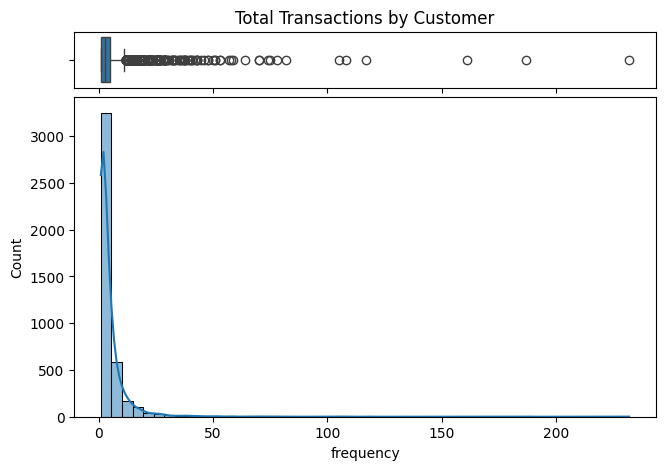

,frequency
0.00,1.0
0.25,1.0
0.50,3.0
0.75,5.0
1.00,232.0


In [29]:
grid = {
    'height_ratios': (0.15, 0.85),
    'hspace': 0.05
}

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(7.5, 5), gridspec_kw=grid)

sns.boxplot(data=df_customer, x='frequency', ax=ax1)
sns.histplot(data=df_customer, x='frequency', kde=True, ax=ax2, bins=50)

ax1.set(
    title='Total Transactions by Customer'
)

plt.show()

display(df_customer['frequency'].quantile([0, 0.25, 0.5, 0.75, 1]))

Based on the distribution above, we will group customers based on their frequency into four groups, referring to the number of transactions we determined:
- 4 (Loyal): made more than 5 transactions
- 3 (High): made 4 to 5 transactions
- 2 (Medium): made 2 to 3 transactions
- 1 (Low): made only 1 transaction.

In [30]:
def f_score(x):
    if x==1:
        return 1
    elif x <= 3:
        return 2
    elif x <= 5:
        return 3
    else:
        return 4

df_customer['f_score'] = df_customer['frequency'].apply(f_score)
df_customer.sample(5, random_state=42)

,recency,customer_age,frequency,monetary,avg_spend_per_product,r_score,f_score
CustomerID,,,,,,,
15110,25,320,7,970.25,24.256250,3,4
17655,12,286,6,1962.84,23.937073,4,4
18200,107,107,1,163.80,5.118750,2,1
12573,229,229,1,160.54,5.733571,1,1
15797,97,321,4,2207.40,275.925000,2,3


**Monetary Segmentation**

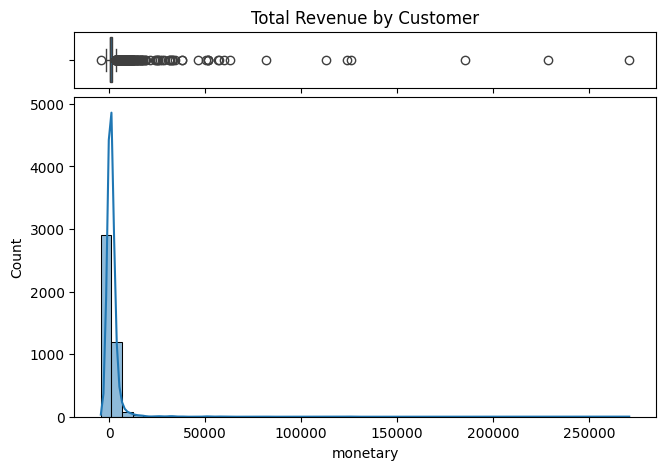

,monetary
0.00,-4287.630
0.25,290.955
0.50,642.485
0.75,1563.750
1.00,270897.140


In [31]:
grid = {
    'height_ratios': (0.15, 0.85),
    'hspace': 0.05
}

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(7.5, 5), gridspec_kw=grid)

sns.boxplot(data=df_customer, x='monetary', ax=ax1)
sns.histplot(data=df_customer, x='monetary', kde=True, ax=ax2, bins=50)

ax1.set(
    title='Total Revenue by Customer'
)

plt.show()

display(df_customer['monetary'].quantile([0, 0.25, 0.5, 0.75, 1]))

Based on the distribution above, we will group customers based on their monetary value into four groups:
* 4 (Top Spender): transactions exceeding USD 1,563.75
* 3 (High Spender): transactions between USD 642.48 and USD 1,563.75
* 2 (Medium Spender): transactions between USD 290.95 and USD 642.48
* 1 (Low Spender): transactions less than USD 290.95

In [32]:
df_customer['m_score'] = pd.qcut(df_customer['monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)
df_customer.sample(5, random_state=42)

,recency,customer_age,frequency,monetary,avg_spend_per_product,r_score,f_score,m_score
CustomerID,,,,,,,,
15110,25,320,7,970.25,24.256250,3,4,3
17655,12,286,6,1962.84,23.937073,4,4,4
18200,107,107,1,163.80,5.118750,2,1,1
12573,229,229,1,160.54,5.733571,1,1,1
15797,97,321,4,2207.40,275.925000,2,3,4


**RFM Segmentation**

Next, we will combine the r score, f score, and m_score into rfm_score.

In [33]:
df_customer['rfm_score'] = df_customer['r_score'] + df_customer['f_score'] + df_customer['m_score']
df_customer.sample(5, random_state=42)

,recency,customer_age,frequency,monetary,avg_spend_per_product,r_score,f_score,m_score,rfm_score
CustomerID,,,,,,,,,
15110,25,320,7,970.25,24.256250,3,4,3,10
17655,12,286,6,1962.84,23.937073,4,4,4,12
18200,107,107,1,163.80,5.118750,2,1,1,4
12573,229,229,1,160.54,5.733571,1,1,1,3
15797,97,321,4,2207.40,275.925000,2,3,4,9


Then we will group it into 4 segments with the following provisions:

In [34]:
def rfm_segmentation(x):
    if x <= 5:
        return 'Bronze'
    elif x <= 7:
        return 'Silver'
    elif x <= 10:
        return 'Gold'
    else:
        return 'Platinum'

df_customer['rfm_level'] = df_customer['rfm_score'].apply(rfm_segmentation)
df_customer.sample(5, random_state=42)

,recency,customer_age,frequency,monetary,avg_spend_per_product,r_score,f_score,m_score,rfm_score,rfm_level
CustomerID,,,,,,,,,,
15110,25,320,7,970.25,24.256250,3,4,3,10,Gold
17655,12,286,6,1962.84,23.937073,4,4,4,12,Platinum
18200,107,107,1,163.80,5.118750,2,1,1,4,Bronze
12573,229,229,1,160.54,5.733571,1,1,1,3,Bronze
15797,97,321,4,2207.40,275.925000,2,3,4,9,Gold


We will try to display it in the form of a visualization as follows:

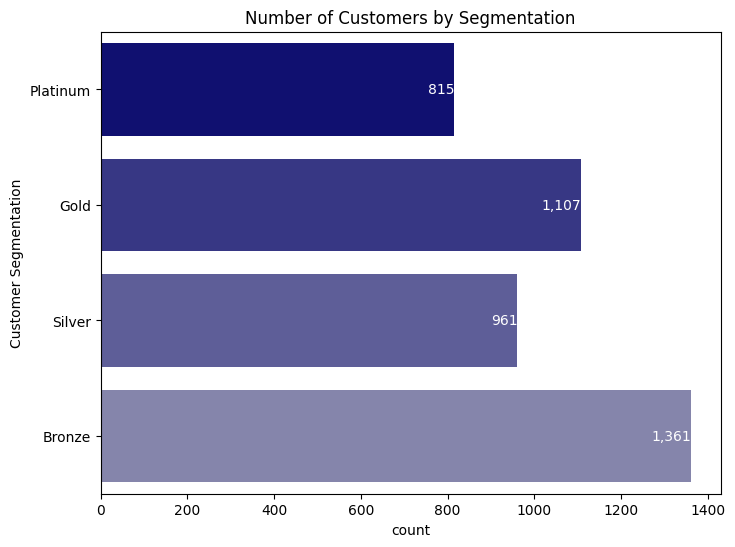

In [41]:
color_palette= sns.blend_palette(['navy', 'lightgrey'])

# create figures
fig, ax = plt.subplots(figsize=(8,6))

# create plots
ax = sns.countplot(
  data=df_customer,
  y='rfm_level',
  order=['Platinum', 'Gold', 'Silver', 'Bronze'],
  palette=color_palette
)

# set title and label
ax.set(
  title='Number of Customers by Segmentation',
  ylabel='Customer Segmentation'
)

# add data labels
for bar in ax.patches:
  x, y = bar.get_xy()
  ax.text(
    x + bar.get_width(),
    y + bar.get_height()/2,
    f'{bar.get_width():,.0f}',
    color='white',
    ha='right',
    va='center'
  )

plt.show()

The summary in tabular form is as follows:

In [42]:
rfm_segment = df_customer.groupby('rfm_level').agg(
    n_customer=('recency', 'count'),
    median_recency=('recency', 'median'),
    median_frequency=('frequency', 'median'),
    median_monetary=('monetary', 'median'),
).sort_values('median_monetary')
rfm_segment

,n_customer,median_recency,median_frequency,median_monetary
rfm_level,,,,
Bronze,1361,179.0,1.0,222.99
Silver,961,66.0,2.0,502.09
Gold,1107,32.0,4.0,1078.96
Platinum,815,13.0,10.0,3000.36


From the visualization and table above, we can summarize and recommend the following:

| Segment | Description | Strategy |
| --- | --- | --- |
| Platinum | Purchased in the last month with a very high transaction value and frequency (~10). | Focus on increasing customer purchases, requiring a cross-selling/upselling strategy and personalized recommendations.
| Gold | Purchased in the last month with a relatively high transaction value but moderate frequency (~4) | Focus on encouraging customers to repurchase, requiring a retention strategy and cross-selling strategy. |
| Silver | Purchased in the last two months with a moderate transaction value but low frequency (~2). | Customers in this segment are at high risk of churn, so focus on activating customers and encouraging them to repurchase by developing a reactivation strategy and retention strategy. |
| Bronze | Purchased in the last six months with a small transaction value and frequency of approximately one purchase. |Customers in this segment have likely churned, so the campaign should focus on reactivating them by developing a reactivation strategy.

In [43]:
# Visualization using plotly
# pip install plotly
import plotly.express as px

color_map = {'Bronze' : 'blue', 'Silver' : 'green', 'Gold' : 'orange', 'Platinum' : 'red'}

fig = px.scatter_3d(
    df_customer,
    x='recency',
    y='frequency',
    z='monetary',
    color='rfm_level',
    color_discrete_map=color_map,
)

fig.update_traces(marker_size = 3)

# tight layout
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0),
                  title={
                    'text': "RFM segmentation",
                    'y':0.97,
                    'x':0.45,
                    'xanchor': 'center',
                    'yanchor': 'top'},
                   legend=dict(
                      yanchor="top",
                      y=0.97,
                      xanchor="left",
                      x=0.70,
                      itemsizing='constant',
                      itemwidth = 30))

fig.update_xaxes(tickformat=".0f")